# SENSEI — Session Intelligence
## Module 3c · Behavioral States — Clustering Pipeline

Builds the final behavioral state labels using K-Means (k=5) on log1p-transformed features.

**Inputs from diagnostic notebooks:**
- `04_cluster_separability.ipynb`: raw features → degenerate clustering (artefact of skewness)
- `04b_cluster_separability_log.ipynb`: log1p features → genuine structure; k=5 chosen as working point
  (silhouette 0.815, avoids the 478-session micro-cluster present at k=8)

**Output:** `data/sessions_features.parquet` extended with two new columns:
- `behavioral_state` — int 0–4 ordered by engagement level (0 = least engaged)
- `behavioral_state_label` — human-readable string

## Contents
1. Load & transform features (log1p)
2. Fit K-Means k=5
3. Cluster profiles in raw units
4. Assign behavioral state labels
5. PCA scatter colored by state
6. Save to parquet
7. Final summary

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')
RANDOM_STATE = 42
K = 5

## 1. Load & Transform Features

In [12]:
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))
print(f'Loaded: {sessions.shape[0]:,} sessions, {sessions.shape[1]} columns')
print(f'Existing columns: {list(sessions.columns)}')

BEHAVIORAL = [
    'n_views', 'n_addtocart', 'n_items', 'n_revisited_items',
    'duration_sec', 'view_to_cart_ratio', 'is_first_session',
]
LOG_FEATURES = ['n_views', 'n_addtocart', 'n_items', 'n_revisited_items', 'duration_sec']

X_raw = sessions[BEHAVIORAL].copy()
X_transformed = X_raw.copy()
X_transformed[LOG_FEATURES] = np.log1p(X_raw[LOG_FEATURES])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)
print(f'log1p applied + scaled: {X_scaled.shape}')

Loaded: 1,761,675 sessions, 14 columns
Existing columns: ['session_id', 'visitorid', 'n_views', 'n_addtocart', 'n_items', 'duration_sec', 'purchased', 'n_revisited_items', 'hour_of_day', 'day_of_week', 'view_to_cart_ratio', 'is_first_session', 'behavioral_state', 'behavioral_state_label']
log1p applied + scaled: (1761675, 7)


## 2. Fit K-Means k=5

In [13]:
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
km_labels = km.fit_predict(X_scaled)

print(f'K-Means converged in {km.n_iter_} iterations')
print(f'Inertia: {km.inertia_:,.0f}')
print(f'Cluster sizes: {dict(zip(*np.unique(km_labels, return_counts=True)))}')

K-Means converged in 6 iterations
Inertia: 3,771,277
Cluster sizes: {0: 1129075, 1: 283243, 2: 34603, 3: 52373, 4: 262381}


## 3. Cluster Profiles in Raw Units

Profiles are computed in **original (raw) units** — not log-space —
so that the feature means are directly interpretable.

In [14]:
sessions['_km_label'] = km_labels

profile = (
    sessions.groupby('_km_label')[BEHAVIORAL + ['purchased']]
    .mean()
    .round(3)
)
profile['n_sessions']      = sessions.groupby('_km_label').size()
profile['pct_sessions']    = (profile['n_sessions'] / len(sessions) * 100).round(1)
profile['purchase_rate_%'] = (profile['purchased'] * 100).round(3)
profile = profile.drop(columns=['purchased'])

print('Raw cluster profiles (k=5):')
print(profile.T.to_string())

Raw cluster profiles (k=5):
_km_label                     0           1          2          3           4
n_views                   0.998       2.445      3.209      8.843       1.031
n_addtocart               0.003       0.000      1.672      0.134       0.005
n_items                   1.001       1.837      2.574      6.416       1.036
n_revisited_items         0.000       0.503      0.607      1.491       0.003
duration_sec              0.112     328.005    741.141   1266.427       1.528
view_to_cart_ratio        0.000       0.000      0.737      0.011       0.000
is_first_session          1.000       0.788      0.698      0.597       0.000
n_sessions          1129075.000  283243.000  34603.000  52373.000  262381.000
pct_sessions             64.100      16.100      2.000      3.000      14.900
purchase_rate_%           0.100       0.300     27.400      3.900       0.500


## 4. Assign Behavioral State Labels

Labels are assigned **data-driven**, not by cluster ID:

1. Sort the 5 clusters by `purchase_rate_%` (monotonically tracks engagement level).
2. Map sorted rank → `behavioral_state` int (0 = least engaged, 4 = most engaged).
3. Assign a human-readable label based on the dominant feature profile of each rank.

This avoids dependency on arbitrary K-Means cluster numbering.

In [15]:
# Sort clusters by purchase rate — engagement ladder proxy
ranked = profile['purchase_rate_%'].sort_values().index.tolist()
# ranked[0] = km cluster with lowest purchase rate (bounce)
# ranked[4] = km cluster with highest purchase rate (most intent)

# Map km cluster id → behavioral state int (0..4)
state_id_map = {km_cluster: state for state, km_cluster in enumerate(ranked)}

# Inspect profiles in engagement order to assign names
print('Clusters ordered by purchase rate (lowest → highest):')
print(profile.loc[ranked, ['n_views', 'n_addtocart', 'duration_sec',
                            'view_to_cart_ratio', 'is_first_session',
                            'pct_sessions', 'purchase_rate_%']].to_string())
print()
print('State mapping (km_cluster → behavioral_state):')
for km_c, state in state_id_map.items():
    pr = profile.loc[km_c, 'purchase_rate_%']
    pct = profile.loc[km_c, 'pct_sessions']
    print(f'  km={km_c} → state={state}  ({pct:.1f}% of sessions, {pr:.2f}% purchase rate)')

Clusters ordered by purchase rate (lowest → highest):
           n_views  n_addtocart  duration_sec  view_to_cart_ratio  is_first_session  pct_sessions  purchase_rate_%
_km_label                                                                                                         
0            0.998        0.003         0.112               0.000             1.000          64.1              0.1
1            2.445        0.000       328.005               0.000             0.788          16.1              0.3
4            1.031        0.005         1.528               0.000             0.000          14.9              0.5
3            8.843        0.134      1266.427               0.011             0.597           3.0              3.9
2            3.209        1.672       741.141               0.737             0.698           2.0             27.4

State mapping (km_cluster → behavioral_state):
  km=0 → state=0  (64.1% of sessions, 0.10% purchase rate)
  km=1 → state=1  (16.1% of sessio

In [16]:
STATE_LABELS = {
    0: 'bounce',           # km=0 — 1 view, ~0 s, all first-time visitors. No engagement.
    1: 'light_browser',    # km=1 — 2.4 views, 328 s, mostly first-time. Some browsing, no cart.
    2: 'returning_bounce', # km=4 — 1 view, ~0 s, ALL returning (is_first_session=0).
                           #         Despite higher purchase rate than light_browser (0.5% vs 0.3%),
                           #         engagement is minimal — the rate reflects returning-visitor base.
    3: 'deep_browser',     # km=3 — 8.8 views, 1266 s, 0.13 addtocarts (13% of sessions had cart).
                           #         Primary signal is depth of browsing, not cart intent.
    4: 'cart_adder',       # km=2 — 1.7 addtocarts, 741 s, view_to_cart_ratio 0.74. 27.4% purchase.
                           #         Clear and decisive purchase intent.
}

sessions['behavioral_state']       = sessions['_km_label'].map(state_id_map)
sessions['behavioral_state_label'] = sessions['behavioral_state'].map(STATE_LABELS)
sessions.drop(columns=['_km_label'], inplace=True)

print('Value counts:')
print(sessions['behavioral_state_label'].value_counts().to_string())

Value counts:
behavioral_state_label
bounce              1129075
light_browser        283243
returning_bounce     262381
deep_browser          52373
cart_adder            34603


## 5. PCA Scatter Colored by Behavioral State

PC1: 48.1%   PC2: 21.9%   Total: 70.0%


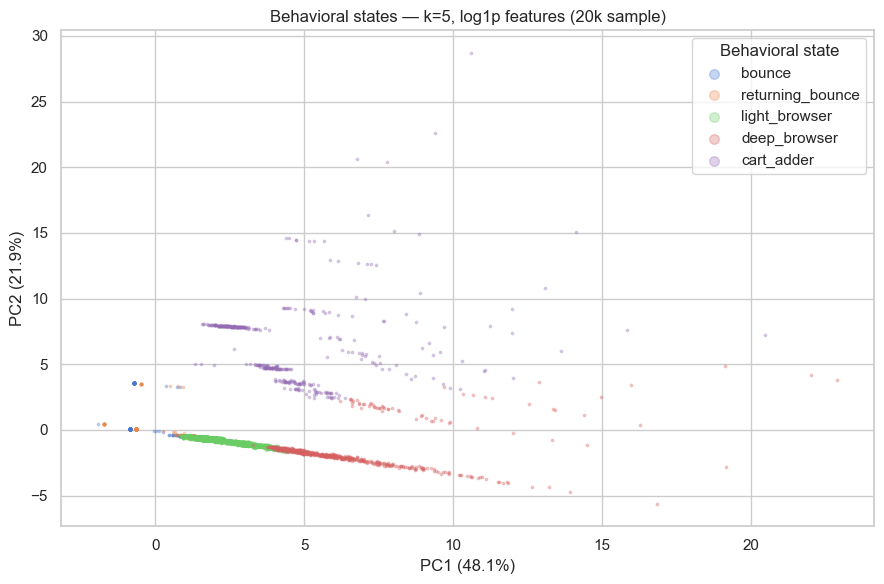

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_
print(f'PC1: {var[0]*100:.1f}%   PC2: {var[1]*100:.1f}%   Total: {sum(var)*100:.1f}%')

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_pca), size=20_000, replace=False)

label_order = ['bounce', 'returning_bounce', 'light_browser', 'deep_browser', 'cart_adder']
palette = dict(zip(label_order, sns.color_palette('muted', n_colors=K)))

fig, ax = plt.subplots(figsize=(9, 6))
for lbl in label_order:
    mask = sessions['behavioral_state_label'].values[idx] == lbl
    ax.scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1],
               s=3, alpha=0.3, color=palette[lbl], label=lbl)

ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax.set_title(f'Behavioral states — k={K}, log1p features (20k sample)')
ax.legend(markerscale=4, title='Behavioral state')
plt.tight_layout()
plt.show()

## 6. Save to Parquet

In [18]:
out_path = os.path.join(DATA_DIR, 'sessions_features.parquet')

# Drop columns if they already exist (re-run safety)
for col in ['behavioral_state', 'behavioral_state_label']:
    if col in sessions.columns and sessions.columns.tolist().count(col) > 0:
        pass  # already present via assignment above — no action needed

sessions.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {sessions.shape}  ({sessions.shape[1]} columns)')
print(f'New columns: behavioral_state, behavioral_state_label')

Saved: ../data/sessions_features.parquet
Shape: (1761675, 14)  (14 columns)
New columns: behavioral_state, behavioral_state_label


## 7. Final Summary

In [19]:
summary = (
    sessions.groupby(['behavioral_state', 'behavioral_state_label'])
    .agg(
        n_sessions=('purchased', 'count'),
        purchase_rate_pct=('purchased', lambda x: round(x.mean() * 100, 2)),
    )
    .reset_index()
    .sort_values('behavioral_state')
)
summary['pct_of_total'] = (summary['n_sessions'] / len(sessions) * 100).round(1)

print('='*65)
print('BEHAVIORAL STATE SUMMARY')
print('='*65)
print(summary[['behavioral_state', 'behavioral_state_label',
               'n_sessions', 'pct_of_total', 'purchase_rate_pct']].to_string(index=False))
print('='*65)
print(f'Total sessions: {len(sessions):,}')
print(f'Overall purchase rate: {sessions["purchased"].mean()*100:.2f}%')
print()
print('These labels are stored in sessions_features.parquet')
print('and will be used as a feature in the purchase intent classifier (notebook 06).')

BEHAVIORAL STATE SUMMARY
 behavioral_state behavioral_state_label  n_sessions  pct_of_total  purchase_rate_pct
                0                 bounce     1129075          64.1               0.06
                1          light_browser      283243          16.1               0.32
                2       returning_bounce      262381          14.9               0.46
                3           deep_browser       52373           3.0               3.85
                4             cart_adder       34603           2.0              27.41
Total sessions: 1,761,675
Overall purchase rate: 0.81%

These labels are stored in sessions_features.parquet
and will be used as a feature in the purchase intent classifier (notebook 06).


## 8. Visualizations

Three plots that together tell the behavioral state story:
1. **Overview** — session volume and purchase rate per state
2. **Feature fingerprint** — normalized feature means as a heatmap (the "profile" of each state)
3. **Within-state distributions** — violin plots for engagement depth and cart activity

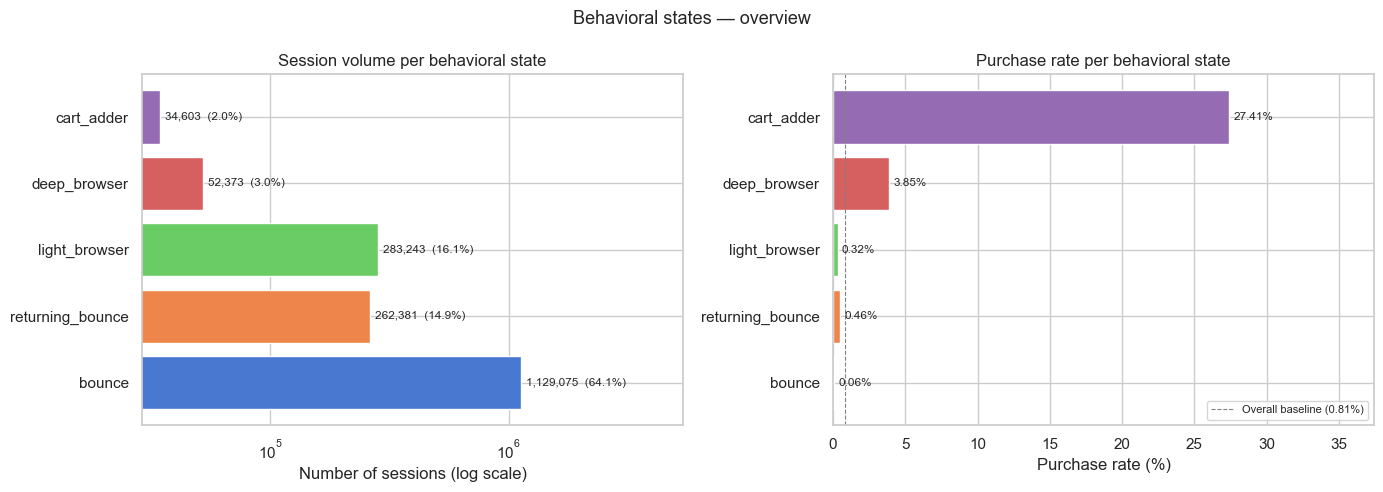

In [20]:
# Consistent color palette and state order for all plots
STATE_ORDER  = ['bounce', 'returning_bounce', 'light_browser', 'deep_browser', 'cart_adder']
STATE_COLORS = dict(zip(STATE_ORDER, sns.color_palette('muted', n_colors=5)))

# Summary frame reused across plots
viz_summary = (
    sessions.groupby('behavioral_state_label')
    .agg(
        n_sessions=('purchased', 'count'),
        purchase_rate=('purchased', lambda x: x.mean() * 100),
    )
    .loc[STATE_ORDER]  # enforce engagement order
)

# ── Plot 1: Session volume (log) + Purchase rate ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — session counts on log scale
colors = [STATE_COLORS[s] for s in STATE_ORDER]
axes[0].barh(STATE_ORDER, viz_summary['n_sessions'], color=colors)
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of sessions (log scale)')
axes[0].set_title('Session volume per behavioral state')
for i, (lbl, row) in enumerate(viz_summary.iterrows()):
    axes[0].text(row['n_sessions'] * 1.05, i,
                 f"{row['n_sessions']:,.0f}  ({row['n_sessions']/len(sessions)*100:.1f}%)",
                 va='center', fontsize=8.5)
axes[0].set_xlim(right=axes[0].get_xlim()[1] * 4)

# Right — purchase rate, linear scale
bars = axes[1].barh(STATE_ORDER, viz_summary['purchase_rate'], color=colors)
axes[1].set_xlabel('Purchase rate (%)')
axes[1].set_title('Purchase rate per behavioral state')
for bar, rate in zip(bars, viz_summary['purchase_rate']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{rate:.2f}%', va='center', fontsize=8.5)
axes[1].set_xlim(right=axes[1].get_xlim()[1] * 1.3)

# Baseline
baseline = sessions['purchased'].mean() * 100
axes[1].axvline(baseline, linestyle='--', color='grey', linewidth=0.8,
                label=f'Overall baseline ({baseline:.2f}%)')
axes[1].legend(fontsize=8)

plt.suptitle('Behavioral states — overview', fontsize=13)
plt.tight_layout()
plt.show()

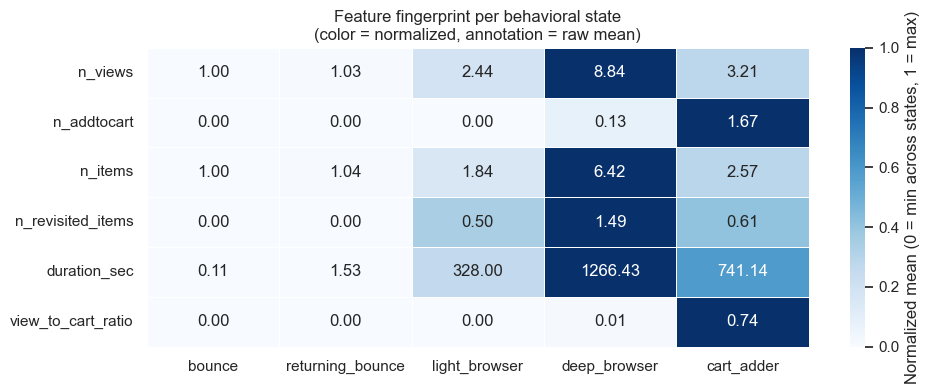

In [21]:
# ── Plot 2: Feature fingerprint heatmap ──────────────────────────────────────
HEATMAP_FEATURES = [
    'n_views', 'n_addtocart', 'n_items', 'n_revisited_items',
    'duration_sec', 'view_to_cart_ratio',
]

feat_means = (
    sessions.groupby('behavioral_state_label')[HEATMAP_FEATURES]
    .mean()
    .loc[STATE_ORDER]
)

# Min-max normalize per feature so all columns share the 0–1 scale
feat_norm = (feat_means - feat_means.min()) / (feat_means.max() - feat_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    feat_norm.T,
    annot=feat_means.T.round(2),   # raw values as annotations
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalized mean (0 = min across states, 1 = max)'},
)
ax.set_title('Feature fingerprint per behavioral state\n(color = normalized, annotation = raw mean)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

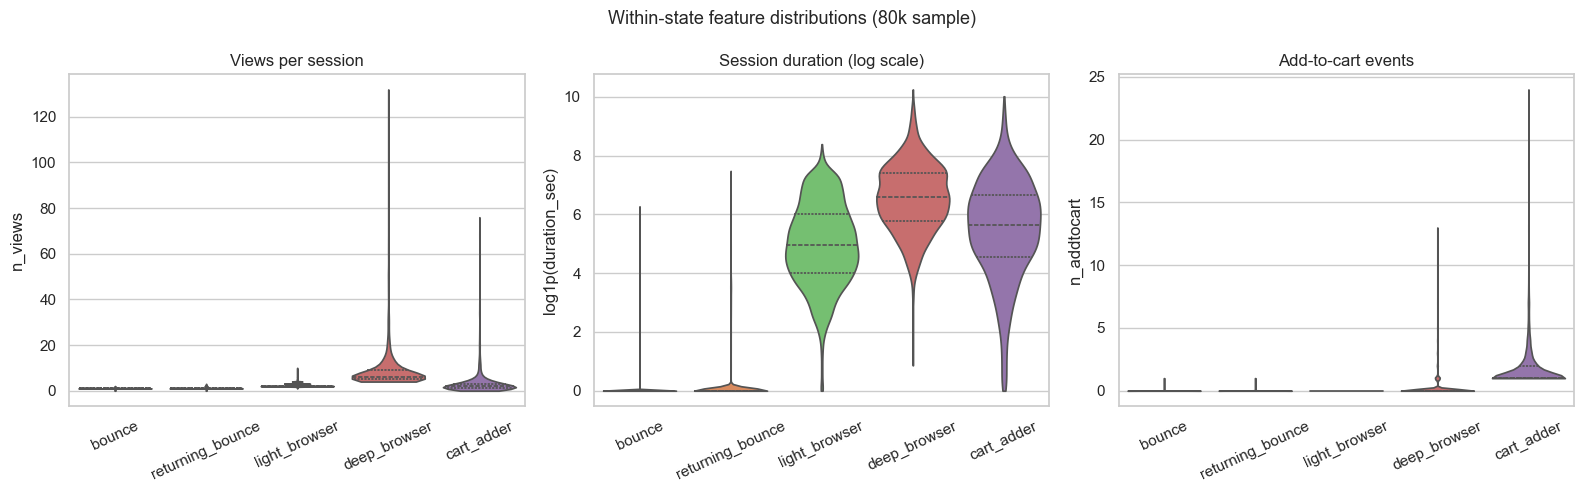

In [22]:
# ── Plot 3: Within-state distributions — violin plots ────────────────────────
# Sample to keep rendering fast; 80k preserves shape well.
sample = sessions.sample(80_000, random_state=RANDOM_STATE).copy()
sample['log_duration'] = np.log1p(sample['duration_sec'])
sample['behavioral_state_label'] = pd.Categorical(
    sample['behavioral_state_label'], categories=STATE_ORDER, ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, ylabel in [
    (axes[0], 'n_views',      'Views per session',           'n_views'),
    (axes[1], 'log_duration', 'Session duration (log scale)', 'log1p(duration_sec)'),
    (axes[2], 'n_addtocart',  'Add-to-cart events',          'n_addtocart'),
]:
    sns.violinplot(
        data=sample, x='behavioral_state_label', y=col,
        hue='behavioral_state_label', palette=STATE_COLORS,
        order=STATE_ORDER, cut=0, inner='quartile',
        legend=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Within-state feature distributions (80k sample)', fontsize=13)
plt.tight_layout()
plt.show()